In [37]:
import tensorflow as tf
from keras import datasets, layers, models
from keras.callbacks import LambdaCallback
import matplotlib.pyplot as plt
import numpy as np


In [10]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

In [11]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [12]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

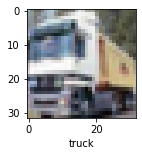

In [14]:
plot_sample(X_train, y_train, 1)

In [15]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [52]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [53]:
weights=[]
getweights = LambdaCallback(on_epoch_end=lambda batch, logs: weights.append(cnn.layers[-1].get_weights()[1]))


In [54]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

In [59]:
 history = cnn.fit(X_train, y_train, epochs=10, callbacks=[getweights])

Epoch 1/10
1563/1563 [==============================] - 73s 47ms/step - loss: 0.5635 - accuracy: 0.8023
Epoch 2/10
1563/1563 [==============================] - 73s 46ms/step - loss: 0.5276 - accuracy: 0.8156
Epoch 3/10
1563/1563 [==============================] - 71s 45ms/step - loss: 0.5007 - accuracy: 0.8229
Epoch 4/10
1563/1563 [==============================] - 69s 44ms/step - loss: 0.4722 - accuracy: 0.8309
Epoch 5/10
1563/1563 [==============================] - 70s 45ms/step - loss: 0.4426 - accuracy: 0.8432
Epoch 6/10
1563/1563 [==============================] - 73s 47ms/step - loss: 0.4143 - accuracy: 0.8520
Epoch 7/10
1563/1563 [==============================] - 73s 46ms/step - loss: 0.3893 - accuracy: 0.8621
Epoch 8/10
1563/1563 [==============================] - 73s 47ms/step - loss: 0.3658 - accuracy: 0.8695
Epoch 9/10
1563/1563 [==============================] - 73s 47ms/step - loss: 0.3440 - accuracy: 0.8783
Epoch 10/10
1563/1563 [==============================] - 72s 46m

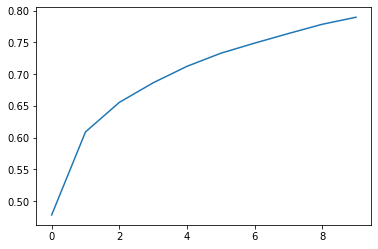

In [56]:
plt.plot(history.history['accuracy'])
plt.show()

In [58]:
weights[0]

IndexError: ignored